# Heart Rate Interval Segmentation with Neural Network

This notebook implements a neural network classifier with variational regularization to automatically detect workout interval boundaries from heart rate time series data.

**How it works:**
1. **Feature Engineering**: Uses the 39 engineered features (statistical, temporal, derivative features, session-normalized values, workout structure metadata, look-ahead/look-behind features). Features are computed per session.

2. **Training Approach**: The model is trained on **multiple workout sessions combined** (not per-session). All training sessions are pooled together into a single dataset, allowing the model to learn generalizable patterns across different athletes and workout types.

3. **Neural Network Architecture**:
   - Encoder compresses 39 features → 128 → 32 → 12-dimensional latent distribution
   - Stochastic sampling via reparameterization trick
   - Decoder predicts boundary probability: 12 → 32 → 128 → 1 (sigmoid output)

4. **Classification**: The network learns to classify each time point as either a boundary or non-boundary through supervised training with weighted binary cross-entropy loss plus minimal KL regularization.

5. **Post-Processing**: Applies adaptive peak detection to the predicted probability curve, constraining results to match the expected number of intervals per session.

**Key Features:**
- Architecture and hyperparameters optimized through Optuna (50 trials)
- Handles class imbalance via positive class weighting (`pos_weight=60.0`)
- Evaluates with time tolerance (±10 seconds) to account for natural variability in boundary timing
- F-beta metric (2:1 recall bias) prioritizes finding all boundaries over precision

## Imports and Environment Setup

Import all required libraries and configure reproducibility settings.

In [12]:
# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================

import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Imports complete")

✓ Imports complete


## Configuration

Define hyperparameters

In [13]:
# ============================================================================
# 2. CONFIGURATION
# ============================================================================

@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123

    # Feature engineering windows (in seconds)
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60

    # Post-processing for peak detection
    peak_distance: int = 20
    peak_prominence: float = 0.15
    smooth_sigma: float = 3.0

CONFIG = Config()
print(f"✓ Configuration set")

✓ Configuration set


## Data Configuration

Specify athlete data directories and test session splits.

- **Training data:** 75 sessions
- **Test data:** 18 sessions

In [14]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialRowing": {
    "sport": "rowing",
    "ftp": None,
    "fit_dir": None,
    "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
    "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## Feature Engineering

Extract 39 engineered features from raw heart rate time series.

**Feature Categories:**

1. **Workout structure** (3 features): intervals_per_minute, expected_interval_length, is_high_density_session
2. **Session-normalized intensity** (9 features): Z-scores, percentile positions, zone indicators
3. **Multi-scale rolling statistics** (7 features): Smoothed HR, rolling max/min/std/range
4. **Temporal derivatives** (9 features): Rate of change at 5s, 10s, 30s scales
5. **Look-ahead/behind** (8 features): Future HR (30s, 60s), past HR, bidirectional changes
6. **Session constants** (3 features): Global mean, std, IQR

These features provide both local temporal context and global session structure.

In [15]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:

    # Initialize empty DataFrame to store all engineered features (preserves original index/timestamps)
    features = pd.DataFrame(index=df.index)

    # Extract heart rate values as numpy array for faster computation
    hr = df['heart_rate'].values

    # ==================== SESSION-LEVEL STATISTICS ====================
    # Calculate global statistics across the entire workout session
    # These provide context about the overall intensity and variability of the workout
    session_mean = hr.mean()           # Average HR for the session (baseline fitness reference)
    session_std = hr.std()             # Standard deviation (measure of HR variability)
    session_max = hr.max()             # Peak HR reached during session
    session_min = hr.min()             # Lowest HR (typically resting/recovery)
    session_range = session_max - session_min  # Total HR range (intensity span)
    session_p25 = np.percentile(hr, 25)  # 25th percentile (lower quartile - recovery zones)
    session_p75 = np.percentile(hr, 75)  # 75th percentile (upper quartile - high intensity zones)
    session_iqr = session_p75 - session_p25  # Interquartile range (robust measure of spread)

    # ==================== INTERVAL DENSITY FEATURES (Top 2) ====================
    # These features capture workout structure/pacing information
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()  # Total number of seconds in the workout
        # Average length of each interval in seconds (helps model understand workout density)
        expected_interval_length = session_duration / n_expected_intervals
        # How many intervals occur per minute (pacing metric: high = short intervals, low = long intervals)
        intervals_per_minute = n_expected_intervals / (session_duration / 60)

        features['intervals_per_minute'] = intervals_per_minute  # Rank 1 - Most important feature (0.1135)
        features['expected_interval_length'] = expected_interval_length  # Rank 2 - Second most important (0.0714)

    # ==================== SMOOTHED HR ====================
    # Apply rolling averages to reduce noise and reveal underlying trends
    # center=True: window is centered on current point (uses past and future data)
    # min_periods=1: compute even at edges where full window isn't available
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # ==================== NORMALIZED HR FEATURES ====================
    # Z-score normalization: converts HR to "standard deviations from mean"
    # Makes features comparable across different individuals/fitness levels
    # +1e-6 prevents division by zero if std is 0
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)  # Rank 3

    # ==================== TEMPORAL FEATURES ====================
    # Look-ahead features: what is the HR going to be in the future?
    # Negative shift means "look forward in time"
    # These are powerful because boundaries show different HR 30-60s later
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)  # HR 30 seconds in the future - Rank 4
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)  # HR 60 seconds in the future - Rank 5

    # ==================== ROLLING STATISTICS ====================
    # Calculate statistics over medium-sized windows (40s by default)
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    # Range within the window (high range = variable/transitioning HR, low range = steady state)
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']  # Rank 6
    # Standard deviation within window (another variability measure)
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()

    # ==================== RELATIVE FEATURES ====================
    # Difference from long-term baseline (detects deviations from sustained HR level)
    # Positive = above baseline (working hard), negative = below baseline (recovering)
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']  # Rank 7

    # ==================== SESSION-NORMALIZED FEATURES ====================
    # Compare current HR to key session statistics
    features['hr_vs_session_p75'] = hr - session_p75  # Rank 8 - Distance from high-intensity threshold

    # Change from past to future (60s lag to 60s lead = 120s total span)
    # Large positive = HR is rising dramatically, large negative = HR is dropping
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - df['heart_rate'].shift(60)
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)  # Rank 9

    # Where in the session's range are we? (0 = at min, 1 = at max)
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)  # Rank 11
    # What percentage of max HR? (intensity metric)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)  # Rank 12

    # ==================== DERIVATIVES ====================
    # Rate of change over different time scales (velocity of HR change)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)    # Short-term change (5 seconds)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)  # Medium-term change (10 seconds)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)  # Long-term change (30 seconds)

    # Normalized derivatives (makes comparable across different session variabilities)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)  # Rank 13

    # Direct change from historical points (alternative to diff())
    features['hr_change_from_lag60'] = hr - df['heart_rate'].shift(60)  # Rank 14 - Change over last 60s
    features['hr_change_from_lag30'] = hr - df['heart_rate'].shift(30)  # Change over last 30s
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)  # Rank 15

    # ==================== TREND INDICATORS ====================
    # Binary feature: is HR currently increasing?
    # 1 = rising, 0 = falling or steady
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)  # Rank 10

    # ==================== SESSION CONTEXT ====================
    # Flag for high-density workouts (≥20 intervals)
    # These might have different boundary characteristics than low-density workouts
    if n_expected_intervals is not None:
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)  # Rank 16

    # More session comparison features
    features['hr_vs_session_mean'] = hr - session_mean  # Rank 17 - Distance from average
    features['hr_vs_session_p25'] = hr - session_p25    # Rank 18 - Distance from low-intensity threshold
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)  # Rank 19 - Ratio to average

    # ==================== REMAINING FEATURES (Ranks 20-30) ====================
    # Maximum HR in short window (captures local peaks)
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()

    # Zone indicators (binary features for different intensity zones)
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)  # In high-intensity zone (>1 std above mean)
    features['in_low_zone'] = (hr < session_p25).astype(int)  # In recovery/low zone (<25th percentile)

    # Historical HR values (what was HR 30s ago?)
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)

    # Z-score of current HR (standardized deviation from mean)
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)

    # Percentage change over 30s (relative rate of change)
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # Session-level constants (same value for all rows, provides scaling context to model)
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_mean'] = session_mean

    # ==================== CLEAN UP ====================
    # Replace infinite values with NaN (can occur from division operations)
    features = features.replace([np.inf, -np.inf], np.nan)
    # Forward fill then backward fill NaN values (propagate valid values)
    # Finally fill any remaining NaN with 0
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

## Data Loading

Load workout sessions with manual boundary annotations.

In [16]:
# ============================================================================
# 5. DATA LOADING
# ============================================================================

def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data from CSV files."""
    session_data = {}

    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]

        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]

        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue

            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()

                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")

    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 11855866225_In_den_Seilen
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 11838948742_3006_row
✓ Athlete12 - 14313279747_Vernunft_verliert_
✓ Athlete12 - 10652950510_Btchen_fahren
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 14396237986_4659_row
✓ Athlete12 - 11808467517_
✓ Athlete12 - 12036692734_Exhausted
✓ Athlete12 - 14156450361_On_a_mission
✓ Athlete12 - 14174927764_Dunstabzugshaubenselfie
✓ Athlete12 - 11971395278_Use_it_or_lose_it
✓ Athlete12 - 13601462878_Zehnbauer
✓ Athlete12 - 13363035398_SGAktiv
✓ Athlete12 - 12501679452_Zustand_nach_Xtem_Atemwegsin
✓ Athlete12 - 14374019349_Uff
✓ Athlete12 - 14114545767_Dampfnudel
✓ Athlete12 - 12846436186_Synchronflug
✓ Athlete12 - 10674304801_Btchen_fahren_in_Etappen_3
✓ Athlete12 - 13618782252_3x5
✓ Athlete12 - 13918354210_W_Upen
✓ Athlete12 - 12951604563_DienstSport
✓ Athlete12 - 12806981726_Row_Stretch__Stabi
✓ Athlete12 - 14182817844_The_Emptiness_Machine
✓ Athlete12 - 1191206234

## Data Preparation

In [17]:
# ============================================================================
# 6. DATA PREPARATION
# ============================================================================

print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

# Sport counters
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}

# Track which test sessions were found
found_test_sessions = set()

# Loop through all sessions and prepare features + labels
for (athlete, session), df in hr_session_data.items():
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()

    # Create features
    features_df = create_hr_features(df, CONFIG, n_expected_intervals=n_intervals)
    X = features_df.values

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue

    sport = athletes[athlete]['sport']

    session_info = {
        'athlete': athlete,
        'session': session,
        'sport': sport,
        'X': X,
        'y': y,
        'n_intervals': n_intervals,
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df
    }

    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

# Check for missing test sessions
missing_test_sessions = set(test_sessions) - found_test_sessions

if missing_test_sessions:
    print("\n❌ WARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        sport = athletes.get(athlete, {}).get('sport', 'unknown')
        print(f"   {athlete} ({sport}): {session}")
else:
    print("\n✓ All test sessions found successfully")

# Combine all training sessions into single arrays
X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Apply same normalization to test data
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

# Print summary statistics
print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"     - Biking: {train_sport_count['biking']}")
print(f"     - Rowing: {train_sport_count['rowing']}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"     - Biking: {test_sport_count['biking']}")
print(f"     - Rowing: {test_sport_count['rowing']}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

❌ WARNING: The following test sessions were NOT FOUND:
   Athlete12 (rowing): 12989160676_Wohnzimmerromantik

✓ Dataset prepared:
   Training sessions: 75
     - Biking: 24
     - Rowing: 51
   Test sessions: 18
     - Biking: 6
     - Rowing: 12
   Training samples: 278,990 (1428 positive)
   Features: 39


## Evaluation

In [18]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Bipartite greedy matching: closest pairs first, no double matching
    pairs = []
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                pairs.append((abs(time_diff), pred_idx, true_idx))

    pairs.sort()  # closest pairs first
    used_pred = set()
    used_true = set()
    matched_pairs = []

    for dist, pred_idx, true_idx in pairs:
        if pred_idx not in used_pred and true_idx not in used_true:
            matched_pairs.append((pred_idx, true_idx, dist))
            used_pred.add(pred_idx)
            used_true.add(true_idx)

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)
    n_matched = len(matched_pairs)

    precision = n_matched / n_pred if n_pred > 0 else 0
    recall = n_matched / n_true if n_true > 0 else 0

    beta = np.sqrt(2)
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # MAE: all predictions to nearest ground truth (unbounded)
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())
    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

In [19]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    if n_expected_intervals >= 50:
        peak_distance = 3
    elif n_expected_intervals >= 35:
        peak_distance = 5
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance

    # Smooth probabilities
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    # Always start with index 0
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    # Find peaks
    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - select top N candidates with spacing
        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Visualization

In [20]:
# ============================================================================
# 8. VISUALIZATION FUNCTIONS
# ============================================================================

def plot_test_results(test_results, model_name="VAE"):
    """Plot predictions vs ground truth for all test sessions."""

    n_sessions = len(test_results)
    fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

    if n_sessions == 1:
        axes = [axes]

    for idx, result in enumerate(test_results):
        df = result['df']
        y_true = result['y_true']
        y_pred = result['y_pred']
        hr_values = df['heart_rate'].values

        # Create twin axis for power
        ax1 = axes[idx]
        ax2 = ax1.twinx()

        # Plot heart rate (RED)
        ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

        # Plot power (BLUE)
        if 'power' in df.columns:
            power_values = df['power'].values
            ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
            ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
            ax2.tick_params(axis='y', labelcolor='blue')

        # Get change points
        gt_cps = np.where(y_true == 1)[0]
        pred_cps = np.where(y_pred == 1)[0]

        # Mark ground truth (GREEN dotted lines)
        for cp in gt_cps:
            if cp < len(hr_values):
                ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                           alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

        # Mark predictions (YELLOW X)
        for cp in pred_cps:
            if cp < len(hr_values):
                ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                           linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

        # Title with metrics
        ax1.set_title(
            f"{model_name} | {result['athlete']} | {result['session']}\n"
            f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
            f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
            fontsize=10, pad=10
        )

        ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
        ax1.set_xlabel('Time (seconds)', fontsize=10)
        ax1.tick_params(axis='y', labelcolor='red')
        ax1.grid(True, alpha=0.3)

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        if 'power' in df.columns:
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        else:
            ax1.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Model Definition

In [21]:
# ============================================================================
# 9. NEURAL NETWORK MODEL DEFINITION (WITH OPTIMIZED HYPERPARAMETERS)
# ============================================================================

class NeuralNetworkClassifier(keras.Model):
    """
    Neural Network with variational regularization for interval boundary detection.
    Uses weighted reconstruction loss to handle class imbalance.
    Architecture uses optimized hyperparameters from Optuna (Trial 6).
    """

    def __init__(self, input_dim, latent_dim=12, hidden_1=128, hidden_2=32, dropout=0.0):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder (with optimized sizes)
        self.enc1 = layers.Dense(hidden_1, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout1 = layers.Dropout(dropout)
        self.enc2 = layers.Dense(hidden_2, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout2 = layers.Dropout(dropout)

        self.z_mean = layers.Dense(latent_dim, kernel_initializer='glorot_uniform')
        self.z_log_var = layers.Dense(latent_dim, kernel_initializer='glorot_uniform')

        # Decoder (symmetric architecture)
        self.dec1 = layers.Dense(hidden_2, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout3 = layers.Dropout(dropout)
        self.dec2 = layers.Dense(hidden_1, activation='relu', kernel_initializer='glorot_uniform')
        self.dropout4 = layers.Dropout(dropout)
        self.dec_out = layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')

    def encode(self, x, training=False):
        h = self.enc1(x)
        h = self.dropout1(h, training=training)
        h = self.enc2(h)
        h = self.dropout2(h, training=training)
        return self.z_mean(h), self.z_log_var(h)

    def reparameterize(self, z_mean, z_log_var):
        z_log_var = tf.clip_by_value(z_log_var, -5, 5)
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def decode(self, z, training=False):
        h = self.dec1(z)
        h = self.dropout3(h, training=training)
        h = self.dec2(h)
        h = self.dropout4(h, training=training)
        return self.dec_out(h)

    def call(self, x, training=False):
        z_mean, z_log_var = self.encode(x, training=training)
        z = self.reparameterize(z_mean, z_log_var)
        return self.decode(z, training=training), z_mean, z_log_var


def nn_loss_with_regularization(y_true, y_pred, z_mean, z_log_var, pos_weight=60.0, beta=0.000148655):
    """
    Neural network loss with class-weighted reconstruction loss and variational regularization.
    """

    y_true = tf.reshape(y_true, [-1, 1])
    y_pred = tf.reshape(y_pred, [-1, 1])
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

    # Weighted binary crossentropy
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weights = tf.where(y_true == 1, pos_weight, 1.0)
    recon_loss = tf.reduce_mean(bce * weights)

    # Variational regularization (KL divergence)
    z_log_var = tf.clip_by_value(z_log_var, -5, 5)
    kl_loss = -0.5 * tf.reduce_mean(
        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
    )

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✓ Neural Network model defined with optimized hyperparameters")

✓ Neural Network model defined with optimized hyperparameters


## Model Training

In [22]:
# ============================================================================
# 10. MODEL TRAINING
# ============================================================================

print("\n" + "="*70)
print("TRAINING NEURAL NETWORK WITH OPTIMIZED HYPERPARAMETERS")
print("="*70)

# Optimized parameters from Optuna (Trial 6)
optimized_latent_dim = 12
optimized_hidden_1 = 128
optimized_hidden_2 = 32
optimized_pos_weight = 60.0
optimized_beta_kl = 0.000148655
optimized_learning_rate = 0.000636
optimized_batch_size = 1024
optimized_dropout = 0.0

print("\nOptimized parameters:")
print(f"  latent_dim: {optimized_latent_dim}")
print(f"  hidden_size_1: {optimized_hidden_1}")
print(f"  hidden_size_2: {optimized_hidden_2}")
print(f"  pos_weight: {optimized_pos_weight}")
print(f"  beta_regularization: {optimized_beta_kl}")
print(f"  learning_rate: {optimized_learning_rate}")
print(f"  batch_size: {optimized_batch_size}")
print(f"  dropout_rate: {optimized_dropout}")

# Create model with optimized architecture
nn_model = NeuralNetworkClassifier(
    input_dim=X_train.shape[1],
    latent_dim=optimized_latent_dim,
    hidden_1=optimized_hidden_1,
    hidden_2=optimized_hidden_2,
    dropout=optimized_dropout
)

optimizer = keras.optimizers.Adam(learning_rate=optimized_learning_rate)

# Prepare dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(10000).batch(optimized_batch_size)

# Training parameters
n_epochs = 50

print(f"\nTraining for {n_epochs} epochs...")
print(f"(This will take ~20-25 minutes)\n")

for epoch in range(n_epochs):
    epoch_losses = []

    for batch_x, batch_y in train_dataset:
        with tf.GradientTape() as tape:
            y_pred, z_mean, z_log_var = nn_model(batch_x, training=True)
            total_loss, recon_loss, kl_loss = nn_loss_with_regularization(
                batch_y, y_pred, z_mean, z_log_var,
                pos_weight=optimized_pos_weight,
                beta=optimized_beta_kl
            )

            if tf.math.is_nan(total_loss):
                print(f"❌ NaN at epoch {epoch+1}! Stopping...")
                break

        grads = tape.gradient(total_loss, nn_model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, nn_model.trainable_variables))

        epoch_losses.append(total_loss.numpy())

    if tf.math.is_nan(total_loss):
        break

    avg_loss = np.mean(epoch_losses)

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}: Loss={avg_loss:.4f}")

print(f"\n✓ Training complete! Final loss: {avg_loss:.4f}")


TRAINING NEURAL NETWORK WITH OPTIMIZED HYPERPARAMETERS

Optimized parameters:
  latent_dim: 12
  hidden_size_1: 128
  hidden_size_2: 32
  pos_weight: 60.0
  beta_regularization: 0.000148655
  learning_rate: 0.000636
  batch_size: 1024
  dropout_rate: 0.0

Training for 50 epochs...
(This will take ~20-25 minutes)

  Epoch   1: Loss=0.0868
  Epoch   5: Loss=0.0382
  Epoch  10: Loss=0.0356
  Epoch  15: Loss=0.0343
  Epoch  20: Loss=0.0334
  Epoch  25: Loss=0.0329
  Epoch  30: Loss=0.0321
  Epoch  35: Loss=0.0319
  Epoch  40: Loss=0.0310
  Epoch  45: Loss=0.0302
  Epoch  50: Loss=0.0304

✓ Training complete! Final loss: 0.0304


## Model Evaluation

In [23]:
# ============================================================================
# 11. MODEL EVALUATION
# ============================================================================

print("\n" + "="*70)
print("EVALUATING OPTIMIZED VAE ON TEST SESSIONS")
print("="*70)

optimized_results = []

for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    # Predict (training=False turns off dropout)
    y_pred_proba, _, _ = nn_model(X, training=False)
    y_pred_proba = y_pred_proba.numpy().flatten()

    if np.isnan(y_pred_proba).any():
        print(f"⚠️  NaN in {session_info['session']}, skipping...")
        continue

    # Detect peaks
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    # Evaluate
    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)
    metrics.update({
        'athlete': session_info['athlete'],
        'session': session_info['session'],
        'sport': session_info['sport'],
        'n_intervals': n_intervals,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'df': session_info['df']
    })

    optimized_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s} | F_beta: {metrics['f_beta']:.3f}")

# Summary statistics
nn_f_beta = np.mean([r['f_beta'] for r in optimized_results])
nn_precision = np.mean([r['precision'] for r in optimized_results])
nn_recall = np.mean([r['recall'] for r in optimized_results])

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)
print(f"  F_beta:    {nn_f_beta:.3f}")
print(f"  Precision: {nn_precision:.3f}")
print(f"  Recall:    {nn_recall:.3f}")
print("="*70)


EVALUATING OPTIMIZED VAE ON TEST SESSIONS
Athlete12    | 12036692734_Exhausted          | F_beta: 0.667
Athlete12    | 13601462878_Zehnbauer          | F_beta: 0.778
Athlete12    | 12846436186_Synchronflug       | F_beta: 1.000
Athlete12    | 14125110656_Vallah_isch_balla  | F_beta: 0.727
Athlete12    | 13983533934_Technik__30er      | F_beta: 0.636
Athlete12    | 11846980624_Platt_             | F_beta: 0.700
Athlete12    | 13688068283_Luftpresser        | F_beta: 0.818
Athlete12    | 11962243206_Wundmanagement     | F_beta: 1.000
Athlete12    | 12069656901_Schwitzen_im_Sitze | F_beta: 0.429
Athlete12    | 14089880174_Zn_IKEA            | F_beta: 0.500
Athlete12    | 11783093951_4x2000_sub8        | F_beta: 0.778
Athlete2     | 13363782092_Zwift__Aerobic_Mix | F_beta: 0.579
Athlete2     | i65696340_Zwift__LC16_Lactate_ | F_beta: 0.625
AthletesSpecialBike | 10283878603_Zwift__HIT__HIT_EB | F_beta: 0.750
AthletesSpecialBike | 13557212506_Zwift__HIT__HIT_EB | F_beta: 0.611
AthletesSpeci

## Visualize Results


📊 Plotting NN predictions...


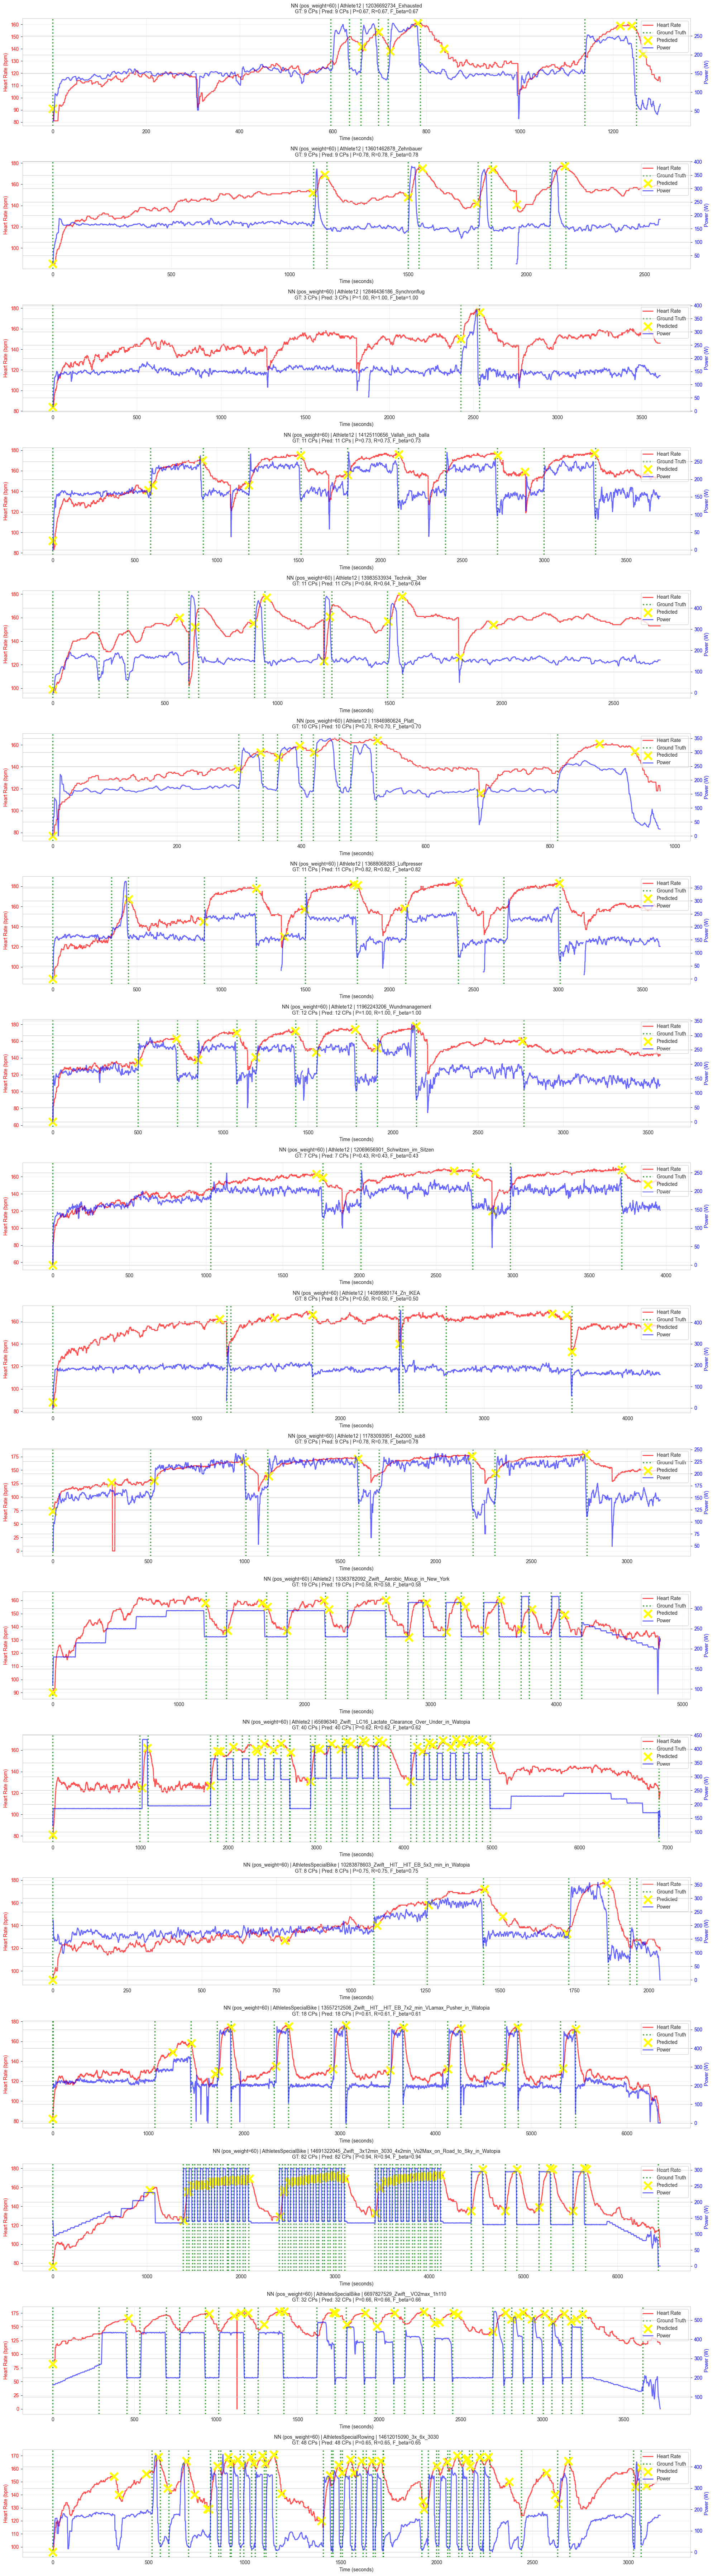

In [24]:
# ============================================================================
# 12. VISUALIZE RESULTS
# ============================================================================

print("\n📊 Plotting NN predictions...")
plot_test_results(optimized_results, model_name="NN (pos_weight=60)")

## Saving NN Model Results

In [25]:
# Save NN results
import pickle

nn_results = {
    'model_name': 'NN',
    'results': optimized_results,  # Your list of dicts with f_beta, precision, recall per session
}

with open('results/nn_results.pkl', 'wb') as f:
    pickle.dump(nn_results, f)

print(f"✓ Saved {len(optimized_results)} NN results")

✓ Saved 18 NN results
